In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedsamir1598/glyphdataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ahmedsamir1598/glyphdataset


# Project Workflow: Egyptian Hieroglyph Recognition with CNN

This project aims to train a Convolutional Neural Network (CNN) to recognize Egyptian hieroglyphs using the Franken dataset.  
We begin with a strict baseline model trained **from scratch**, without data augmentation or pretrained models.

---

# Phase 1: Data Understanding and Preparation

## Step 1 – Select the Dataset
We use the **Manual → Preprocessed** images from the dataset.

Reason:
- These images were **manually labeled**
- Labels are more **accurate**
- Images are already **resized to 50×75**

The **Automated dataset** will not be used for the baseline because it may contain detection errors.

---

## Step 2 – Explore the Dataset
Before training the model, we analyze the dataset to understand its structure.

We examine:
- Total number of images
- Total number of glyph classes
- Number of images per class

This helps identify classes that have too few examples.

---

## Step 3 – Remove Classes with Very Few Samples
Some glyph classes may contain only a few images.

Rule for the baseline experiment:
- Remove classes that contain **fewer than 5 images**

Reason:
A CNN cannot learn the shape of a glyph from only a few examples.

A list of removed classes will be recorded for documentation.

---

## Step 4 – Image Normalization
Each image is prepared so the neural network can process it correctly.

Processing steps:
1. Load the image
2. Ensure the image is grayscale
3. Normalize pixel values from **0–255 to 0–1**

Normalization helps the model learn more efficiently.

---

## Step 5 – Label Encoding
Each hieroglyph has a **Gardiner code**, such as:

- A01
- D58
- G17

Neural networks require numerical labels.

Therefore, each label is converted into a numeric class ID.

Example:

- A01 → 0  
- D58 → 1  
- G17 → 2  

This process is called **label encoding**.

---

## Step 6 – Dataset Splitting
The dataset is divided into three subsets:

- **Training Set (70%)**
  - Used to train the CNN

- **Validation Set (15%)**
  - Used to monitor model performance during training

- **Test Set (15%)**
  - Used for final evaluation

The split is **stratified**, ensuring that every class appears in all subsets.

---

# Phase 2: Baseline CNN Model

## Step 7 – Build a Small CNN
A simple Convolutional Neural Network is used for the baseline.

Reason:
- The dataset is relatively small (~4000 images)
- Smaller networks reduce the risk of overfitting

The CNN will learn visual features such as:
- edges
- curves
- shapes of hieroglyphs

---

## Step 8 – Prevent Overfitting
Because the baseline model **does not use data augmentation**, additional regularization techniques are applied.

Two strategies are used:

### Dropout
Randomly disables neurons during training to prevent memorization.

### Early Stopping
Training stops automatically if the validation score stops improving.

This prevents the model from overfitting the training data.

---

## Step 9 – Model Training
The CNN is trained using the **training dataset**.

During training we monitor:

- Training accuracy
- Validation accuracy
- Validation loss

If validation performance stops improving, training ends early.

---

# Phase 3: Model Evaluation

## Step 10 – Test the Model
After training is complete, the model is evaluated using the **test dataset**.

This measures how well the model recognizes glyphs it has **never seen before**.

---

## Step 11 – Performance Analysis
Model performance is analyzed using:

### Accuracy
Overall percentage of correct predictions.

### Confusion Matrix
Shows which glyphs are frequently confused with others.

### Per-Class Accuracy
Identifies which glyphs are easier or harder to recognize.

---

# Phase 4: Baseline Establishment

The first experiment establishes a **baseline performance**.

Characteristics of the baseline:

- Model trained **from scratch**
- **No data augmentation**
- **No pretrained models**

This baseline provides a **lower bound** for model performance.

---

# Phase 5: Future Improvements

After establishing the baseline, additional experiments will be performed to improve performance.

Potential improvements include:

1. **Data Augmentation**
   - rotations
   - flips
   - zoom transformations

2. **Deeper CNN Architectures**

3. **Transfer Learning**
   - using pretrained vision models

Each improvement will be compared against the baseline.

---

# Summary Workflow

Dataset Selection  
↓  
Dataset Exploration  
↓  
Remove Classes with Few Samples  
↓  
Normalize Images  
↓  
Encode Labels  
↓  
Split Dataset (Train / Validation / Test)  
↓  
Train Baseline CNN  
↓  
Apply Dropout and Early Stopping  
↓  
Evaluate Model on Test Set  
↓  
Record Baseline Results

In [2]:
import os
from collections import Counter

# Path to the dataset
dataset_path = "/kaggle/input/datasets/ahmedsamir1598/glyphdataset/Dataset/Manual/Preprocessed"

total_images = 0
class_counts = {}

# Loop through each class folder
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        num_images = len(images)
        
        class_counts[class_name] = num_images
        total_images += num_images

# Total number of classes
total_classes = len(class_counts)

print("Total number of images:", total_images)
print("Total number of classes:", total_classes)

print("\nImages per class:")
for cls, count in sorted(class_counts.items()):
    print(f"{cls}: {count}")

Total number of images: 4210
Total number of classes: 10

Images per class:
20: 387
21: 360
22: 439
23: 424
3: 464
39: 402
41: 404
5: 455
7: 455
9: 420


Load and Normalize Images

Before we feed the images into a CNN, we need to make sure they are in the right format:

1. **Load each image** from the preprocessed dataset.  
2. **Convert to grayscale** so the network focuses on the glyph shapes, not colors.  
3. **Normalize pixel values** from 0–255 to 0–1. This makes learning easier for the network.  

The result will be a dictionary where each class name maps to a list of normalized image arrays, ready for training.

In [3]:
import cv2

# Dictionary to store images by class
images_by_class = {}

# Iterate over existing classes from class_counts
for class_name in class_counts.keys():
    class_folder = os.path.join(dataset_path, class_name)
    images_by_class[class_name] = []
    
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        
        # Load image
        img = cv2.imread(img_path)
        
        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Normalize pixel values to 0-1
        norm_img = gray / 255.0
        
        images_by_class[class_name].append(norm_img)

print("Images loaded and normalized for each class.")

Images loaded and normalized for each class.


### Label Encoding

Each hieroglyph image has a Gardiner code label, like `A01` or `D58`.  
Neural networks cannot use text labels directly, so we need to **convert each label into a unique number**.  

Example:

- `A01` → 0  
- `D58` → 1  
- `G17` → 2  

This numeric mapping allows the model to learn and predict classes properly.

In [4]:
from sklearn.preprocessing import LabelEncoder

# Assuming you have a list of all class labels
class_labels = list(class_counts.keys())

# Create the label encoder
le = LabelEncoder()
le.fit(class_labels)

# Map each class name to a numeric ID
label_mapping = {label: idx for idx, label in enumerate(le.classes_)}
print("Label mapping:", label_mapping)

Label mapping: {np.str_('20'): 0, np.str_('21'): 1, np.str_('22'): 2, np.str_('23'): 3, np.str_('3'): 4, np.str_('39'): 5, np.str_('41'): 6, np.str_('5'): 7, np.str_('7'): 8, np.str_('9'): 9}


## Dataset Splitting

We split the dataset into three parts:

- **Training Set (70%)**: Used to train the CNN.
- **Validation Set (15%)**: Used to monitor model performance during training.
- **Test Set (15%)**: Used for final evaluation.

The split is **stratified**, which means every class is represented proportionally in each subset.

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Populate X and y by unpacking the dictionary
X = []
y = []

for class_name, img_list in images_by_class.items():
    for img in img_list:
        X.append(img)
        # We use the label_mapping created in your previous step
        y.append(label_mapping[class_name])

# 2. Convert to NumPy arrays for the CNN
X = np.array(X)
y = np.array(y)

# 3. Add the channel dimension (Height, Width, 1)
# CNNs expect 4D input: (Batch_Size, Height, Width, Channels)
h, w = X[0].shape
X = X.reshape(-1, h, w, 1)

print(f"Prepared {len(X)} images for splitting.")

# 4. Split the dataset (70% Train, 30% Temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# 5. Split Temp into Validation and Test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"✅ Training set size: {len(X_train)}")
print(f"✅ Validation set size: {len(X_val)}")
print(f"✅ Test set size: {len(X_test)}")

Prepared 4210 images for splitting.
✅ Training set size: 2947
✅ Validation set size: 631
✅ Test set size: 632


### Baseline CNN Model

#### Step 7 – Build a Small CNN
Now that our data is split, we build the "brain" of the project. Since our dataset is small (~4,210 images) and we aren't using data augmentation yet, we use a **Shallow CNN architecture**. 

**Why this specific design?**
* **Simple Layers:** Deep networks (like ResNet) have millions of parameters and would instantly "memorize" our small dataset instead of learning the shapes.
* **Feature Extraction:** The model uses **Convolutional Layers (Conv2D)** to scan for the edges, curves, and specific strokes that make up a hieroglyph.



#### Understanding the Architecture:
1. **Conv2D (The Filter):** These layers look for simple lines and then combine them into complex shapes (like the wing of a bird or the base of a jar).
2. **Dropout (The Anti-Memorizer):** This randomly "turns off" 20–30% of neurons during training. It forces the model to find multiple ways to recognize a glyph, which prevents **overfitting**.
3. **MaxPooling:** This shrinks the data by half, keeping only the strongest visual signals. This makes the model faster and more robust.
4. **Global Average Pooling (GAP):** Instead of a huge "Flatten" layer, GAP takes a clean average. This is a modern technique to keep the parameter count low.
5. **Dense + Softmax:** The final layer has 10 neurons. The **Softmax** function turns the output into a probability (e.g., "90% confident this is Class 7").

In [6]:
from tensorflow.keras import layers, models

def build_baseline_model(input_shape, num_classes):
    model = models.Sequential([
        # --- Layer 1: The "Edge Finder" ---
        layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape),
        layers.Dropout(0.2), # Prevent memorizing the noise
        
        # --- Layer 2: The "Shape Combiner" ---
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # --- Layer 3: Feature Condensing ---
        # Instead of a huge Flatten layer, we use Global Average Pooling
        # to keep the parameter count low and prevent overfitting.
        layers.GlobalAveragePooling2D(),
        
        # --- Layer 4: The Decision Maker ---
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

# Initialize the model
# Height=75, Width=50, Channels=1
input_shape = (75, 50, 1) 
num_classes = 10 # Based on your class exploration

model = build_baseline_model(input_shape, num_classes)
model.summary()

2026-03-06 23:33:06.493272: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772839986.719922      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772839986.781497      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772839987.300385      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772839987.300426      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772839987.300429      24 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 73, 48, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 73, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 71, 46, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 35, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 35, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,130 (20.04 KB)

 Trainable params: 5,130 (20.04 KB)

 Non-trainable params: 0 (0.00 B)

###  Baseline CNN Model (Continued)

#### Prevent Overfitting (Callbacks)
Because we are training from scratch with a small dataset and **no data augmentation**, the model is at high risk of "memorizing" the training images rather than "learning" the glyph shapes. 

To prevent this, we use two key techniques:
1. **Dropout:** (Already included in the model layers) This randomly disables neurons during each training step.
2. **Early Stopping:** This monitors the **Validation Loss**. If the model stops improving for a set number of rounds (epochs), the training stops automatically. This ensures we don't keep training to the point where the model starts "overthinking" the noise in the data.



#### Model Training
We are now ready to begin the training process. The CNN will pass through the training data multiple times (epochs), adjusting its internal weights to minimize the difference between its predictions and the actual labels.

**What we are monitoring:**
* **Training Accuracy:** How well the model is learning the patterns in the training set.
* **Validation Accuracy:** How well the model generalizes to "new" images it hasn't seen before.
* **Validation Loss:** The "error" score on the validation set. If this starts to rise while training loss falls, we know the model is starting to overfit.

We will run this for a maximum of 50 epochs, but thanks to our **Early Stopping** , the model will "drop the mic" and stop training the moment it feels it has reached its peak performance.

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Setup Early Stopping (Step 8)
# monitor='val_loss': watch the error on data the model hasn't seen
# patience=5: if no improvement for 5 rounds, stop training
# restore_best_weights=True: go back to the version of the model that performed best
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 2. Run the Training Loop (Step 9)
print("Starting Training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop], # Plug in our Step 8 tool here
    verbose=1
)

print("Training Complete!")

Starting Training...
Epoch 1/50


I0000 00:00:1772840012.883932      67 service.cc:152] XLA service 0x79e4e0034000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772840012.883969      67 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772840012.883973      67 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772840013.179702      67 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-06 23:33:34.814903: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 23:33:34.963612: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-06 23:33:35.103201: E external/local_xl

27/93 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1059 - loss: 2.3075

I0000 00:00:1772840017.240520      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.1091 - loss: 2.3052 - val_accuracy: 0.1141 - val_loss: 2.3008
Epoch 2/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0921 - loss: 2.3013 - val_accuracy: 0.1094 - val_loss: 2.3002
Epoch 3/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1041 - loss: 2.3027 - val_accuracy: 0.1141 - val_loss: 2.2990
Epoch 4/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1177 - loss: 2.2989 - val_accuracy: 0.1204 - val_loss: 2.2969
Epoch 5/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1194 - loss: 2.2973 - val_accuracy: 0.1458 - val_loss: 2.2949
Epoch 6/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1286 - loss: 2.2915 - val_accuracy: 0.1696 - val_loss: 2.2910
Epoch 7/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1330 - loss: 2.2872 - val_accuracy: 0.1537 - val_loss: 2.2824
Epoch 8/50
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1518 - loss: 2.2771 - val_accuracy: 0.1315 - val_loss: 2.2652
Ep

### Model Evaluation

#### Test the Model
After the training is halted by Early Stopping, we perform a final evaluation. We use the **Test Set**, which acts as a "blind test." Since the model has never seen these specific images during the training or validation phases, this is the most honest measure of its performance.

**What we are looking for:**
* **Test Accuracy:** The percentage of images in the test set that the model identified correctly.
* **Test Loss:** The numerical error on the test set. 

If the Test Accuracy is close to the Validation Accuracy, it proves our model **generalized well** and didn't just memorize the training data.

--- Final Model Evaluation (Test Set) ---
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3428 - loss: 1.8673

Final Test Results:
Test Accuracy: 0.3481 (34.81%)
Test Loss: 1.8389


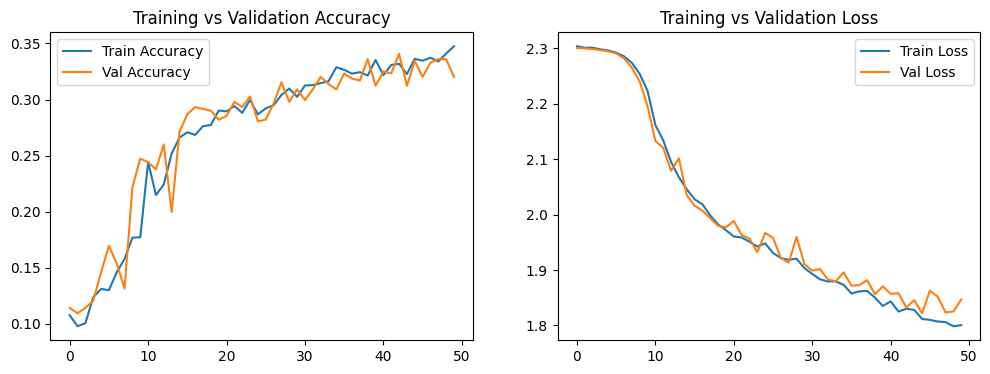

In [8]:
print("--- Final Model Evaluation (Test Set) ---")

# Evaluate the model on the unseen test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print(f"\nFinal Test Results:")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# Optional: Plotting the training history to see the "Story" of the learning
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

#### Performance Analysis
A single accuracy score doesn't tell the whole story. To truly understand our model, we use three specific tools:

1. **Overall Accuracy:** The final "grade" on the test set.
2. **Confusion Matrix:** A heatmap that shows us which classes the model is mixing up. For example, if the model predicts a "Vulture" when the image was actually an "Owl," we will see a high count in that specific cell.
3. **Per-Class Accuracy (Classification Report):** This breaks down performance for every single glyph. It tells us which symbols are "Easy" (high precision) and which ones are "Hard" (low recall) for the CNN to recognize.



By analyzing these, we can decide if our next step (Phase 5) should focus on more data for specific "hard" classes or better image preprocessing.

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


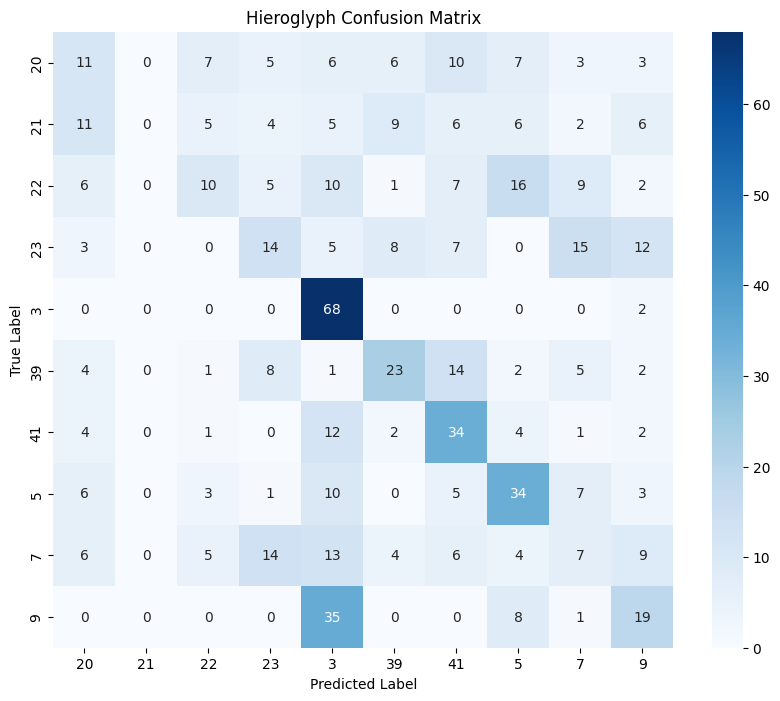


--- Detailed Classification Report ---
              precision    recall  f1-score   support

          20       0.22      0.19      0.20        58
          21       0.00      0.00      0.00        54
          22       0.31      0.15      0.20        66
          23       0.27      0.22      0.24        64
           3       0.41      0.97      0.58        70
          39       0.43      0.38      0.41        60
          41       0.38      0.57      0.46        60
           5       0.42      0.49      0.45        69
           7       0.14      0.10      0.12        68
           9       0.32      0.30      0.31        63

    accuracy                           0.35       632
   macro avg       0.29      0.34      0.30       632
weighted avg       0.30      0.35      0.30       632



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get Model Predictions
# The model outputs probabilities, so we use argmax to get the most likely class ID
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Generate the Confusion Matrix
# We use the original label names (Gardiner codes) for the axis
cm = confusion_matrix(y_test, y_pred)
class_names = list(le.classes_) # These are our 10 hieroglyph names

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Hieroglyph Confusion Matrix')
plt.show()

# 3. Per-Class Accuracy & Detailed Report
print("\n--- Detailed Classification Report ---")
# This shows Precision, Recall, and F1-Score for every single class
print(classification_report(y_test, y_pred, target_names=class_names))